# PCA vs Pearson Feature Selection Test

This notebook compares two versions of the ML predictor strategy:

- **Pearson method:** selects the `n_features` individual indicators with the strongest absolute Pearson correlation to the training target.
- **PCA method:** transforms the full feature matrix into principal components, then feeds the selected components into the same MLP model.

The goal is not only to see which backtest performs better, but also to understand *why* the behavior differs: Pearson keeps original indicators; PCA replaces them with orthogonal linear combinations of indicators.

## 1. Notebook Setup

The path setup below makes the notebook robust whether it is launched from the repo root or directly from `research/Mateo/ML_predictor`.

In [ ]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

cwd = Path.cwd().resolve()
repo_root = cwd
while repo_root.name != "Bluegrey" and repo_root.parent != repo_root:
    repo_root = repo_root.parent

ml_dir = repo_root / "research" / "Mateo" / "ML_predictor"
src_dir = repo_root / "src"

for path in [repo_root, src_dir, ml_dir]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

print(f"Repo root: {repo_root}")
print(f"ML directory: {ml_dir}")

Repo root: /Users/mateo/Bluegrey
ML directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor


In [2]:
from ML_predictor_features_Sharpe import MLPredictorStrategy as PearsonStrategy
from ML_predictor_PCA import MLPredictorStrategy as PCAStrategy
from src.vector_backtester_Mateo import PortfolioVectorEngine

## 2. Experiment Configuration

Both methods should be tested under the same trading assumptions, date range, target definition, MLP settings, Sharpe filter settings, and cost model. The only intentional difference here is the dimensionality-reduction step.

For PCA, `pca_n_components=0.95` means: keep however many principal components are needed to explain 95% of the variance in each rolling training window. For a stricter apples-to-apples component-count test, set it to an integer such as `6`.

The PCA strategy also drops numerically unsafe feature columns before scaling. This matters because some full pandas-ta indicators can produce finite but enormous values (ie, 1e260) that overflow during standardization.

In [3]:
SYMBOL = "SPY"

RUN_CONFIG = {
    "asset_class": "STK",
    "initial_capital": 1_000_000,
    "execution_delay": 1,
}

COMMON_STRATEGY_PARAMS = {
    "symbol": SYMBOL,
    "start_date": "2025-01-01",
    "end_date": "2026-01-01",
    "signal_threshold": 0.002,
    "training_years": 10,
    "download_data": False,
    "sharpe_filter_enabled": False,
    "rolling_sharpe_window": 63,
    "rolling_sharpe_min_periods": 63,
    "rolling_sharpe_annualization": 252,
    "sharpe_enter_threshold": 1.05,
    "sharpe_exit_threshold": 0.95,
    "sharpe_performance_lag": 2,
    "feature_diagnostics_enabled": True,
    "feature_diagnostics_top_n": 10,
    "position_size": 1.0,
    "max_iter": 5000,
    "verbose": False,
}

PEARSON_PARAMS = {
    **COMMON_STRATEGY_PARAMS,
    "n_features": 6,
}

PCA_PARAMS = {
    **COMMON_STRATEGY_PARAMS,
    "pca_n_components": 0.95,
}

SHOW_PROGRESS = True
SHOW_TEARSHEETS = False

## 3. Helper Functions

The helper below deliberately mirrors the logic in the `run_single_case_*` scripts, but returns the intermediate objects. That gives us access to the strategy diagnostics, generated weights, backtester engine, and portfolio stats for comparison.

In [4]:
def annualized_sharpe(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    vol = returns.std()
    if vol == 0 or np.isnan(vol):
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / vol


def annualized_sortino(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    downside = returns[returns < 0]
    downside_vol = downside.std()
    if downside_vol == 0 or np.isnan(downside_vol):
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / downside_vol


def summarize_performance(label: str, stats: pd.DataFrame, weights: pd.DataFrame, initial_capital: float) -> dict:
    gross_return_pct = (stats["gross_equity"].iloc[-1] / initial_capital - 1.0) * 100
    net_return_pct = (stats["net_equity"].iloc[-1] / initial_capital - 1.0) * 100
    benchmark_return_pct = (stats["cum_benchmark"].iloc[-1] - 1.0) * 100

    drawdown = stats["net_equity"] / stats["net_equity"].cummax() - 1.0
    max_drawdown_pct = drawdown.min() * 100

    gross_bar_returns = stats["gross_returns"].iloc[1:]
    win_rate_pct = (gross_bar_returns > 0).mean() * 100
    loss_rate_pct = (gross_bar_returns < 0).mean() * 100
    zero_rate_pct = (gross_bar_returns == 0).mean() * 100

    exposure = weights.abs().sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(0)

    return {
        "method": label,
        "gross_return_pct": gross_return_pct,
        "net_return_pct": net_return_pct,
        "benchmark_return_pct": benchmark_return_pct,
        "excess_vs_benchmark_pct": net_return_pct - benchmark_return_pct,
        "max_drawdown_pct": max_drawdown_pct,
        "net_sharpe": annualized_sharpe(stats["net_returns"]),
        "net_sortino": annualized_sortino(stats["net_returns"]),
        "win_rate_pct": win_rate_pct,
        "loss_rate_pct": loss_rate_pct,
        "zero_rate_pct": zero_rate_pct,
        "active_days_pct": (exposure > 0).mean() * 100,
        "average_abs_exposure": exposure.mean(),
        "average_daily_turnover": turnover.mean(),
        "total_fees_paid": stats["cumulative_costs"].iloc[-1],
    }


def run_backtest_case(label: str, strategy_class, params: dict, run_config: dict, show_progress: bool = True, show_tearsheet: bool = False) -> dict:
    print(f"Running {label}...")
    strategy = strategy_class(params=params)
    dataset = strategy.prepare_dataset()
    weights = strategy.generate_signals(dataset, show_progress=show_progress)

    if weights.empty:
        raise RuntimeError(f"{label} produced empty weights. Check date range and training window.")

    symbol = params["symbol"]
    prices = dataset[["Open"]].rename(columns={"Open": symbol}).loc[weights.index]

    engine = PortfolioVectorEngine(
        prices=prices,
        signals=weights,
        asset_class=run_config["asset_class"],
        initial_capital=run_config["initial_capital"],
        execution_delay=run_config["execution_delay"],
    )

    stats = engine.run()
    if show_tearsheet:
        engine.tearsheet(f"{symbol} {label} ML Walk Forward")

    metrics = summarize_performance(label, stats, weights, run_config["initial_capital"])

    return {
        "label": label,
        "strategy": strategy,
        "dataset": dataset,
        "weights": weights,
        "prices": prices,
        "engine": engine,
        "stats": stats,
        "metrics": metrics,
    }

## 4. Run the Two Methods

This cell can take a while because both strategies retrain the MLP walk-forward at every prediction date.

In [5]:
pearson_result = run_backtest_case(
    label="Pearson",
    strategy_class=PearsonStrategy,
    params=PEARSON_PARAMS,
    run_config=RUN_CONFIG,
    show_progress=SHOW_PROGRESS,
    show_tearsheet=SHOW_TEARSHEETS,
)

pca_result = run_backtest_case(
    label="PCA",
    strategy_class=PCAStrategy,
    params=PCA_PARAMS,
    run_config=RUN_CONFIG,
    show_progress=SHOW_PROGRESS,
    show_tearsheet=SHOW_TEARSHEETS,
)

results = {
    "Pearson": pearson_result,
    "PCA": pca_result,
}

Running Pearson...
🧠 Predicting 2025-12-31 |  250/250 |  last: 0.37s |  elapsed: 1m 31.1s
✅ Prediction complete. Took 1m 31.3s

Running PCA...
🧠 Predicting 2025-12-31 |  250/250 |  last: 1.84s |  elapsed: 7m 23.7s
✅ Prediction complete. Took 7m 25.7s



## 5. Performance Comparison

The table below focuses on comparable portfolio-level outcomes: returns, drawdown, risk-adjusted performance, activity, turnover, and fees.

In [6]:
comparison = pd.DataFrame([result["metrics"] for result in results.values()]).set_index("method")

display(comparison.T.round(4))

method,Pearson,PCA
gross_return_pct,-0.4910,21.8225
net_return_pct,-1.1623,19.0013
benchmark_return_pct,17.9540,17.9540
excess_vs_benchmark_pct,-19.1163,1.0472
max_drawdown_pct,-26.7470,-7.6500
net_sharpe,0.0454,0.9964
net_sortino,0.0469,1.4050
win_rate_pct,57.4297,38.9558
loss_rate_pct,41.3655,36.5462
zero_rate_pct,1.2048,24.4980


In [7]:
delta = comparison.loc["PCA"] - comparison.loc["Pearson"]
delta.name = "PCA_minus_Pearson"

display(delta.to_frame().round(4))

,PCA_minus_Pearson
gross_return_pct,22.3135
net_return_pct,20.1635
benchmark_return_pct,0.0000
excess_vs_benchmark_pct,20.1635
max_drawdown_pct,19.0970
net_sharpe,0.9510
net_sortino,1.3581
win_rate_pct,-18.4739
loss_rate_pct,-4.8193
zero_rate_pct,23.2932


## 6. Equity Curves and Drawdowns

The equity curve tells us whether one method is consistently better, or whether the performance difference comes from a few isolated periods.

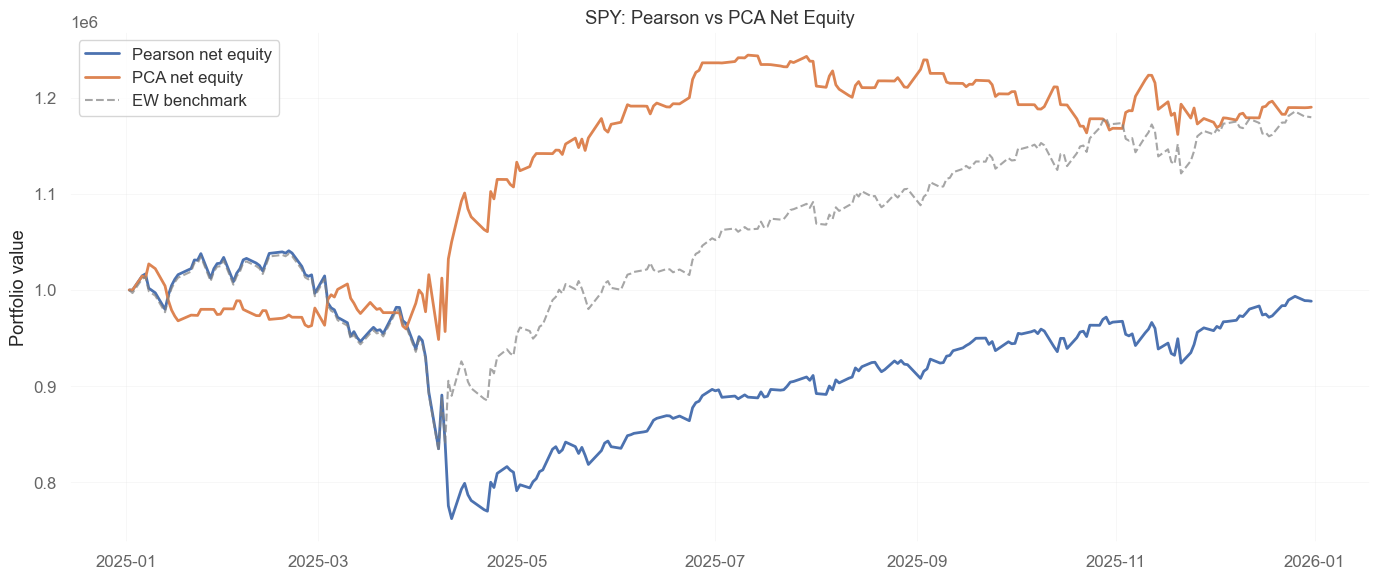

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

for label, result in results.items():
    stats = result["stats"]
    ax.plot(stats.index, stats["net_equity"], label=f"{label} net equity", linewidth=2)

benchmark = RUN_CONFIG["initial_capital"] * pearson_result["stats"]["cum_benchmark"]
ax.plot(benchmark.index, benchmark, label="EW benchmark", color="gray", linestyle="--", alpha=0.7)

ax.set_title(f"{SYMBOL}: Pearson vs PCA Net Equity")
ax.set_ylabel("Portfolio value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

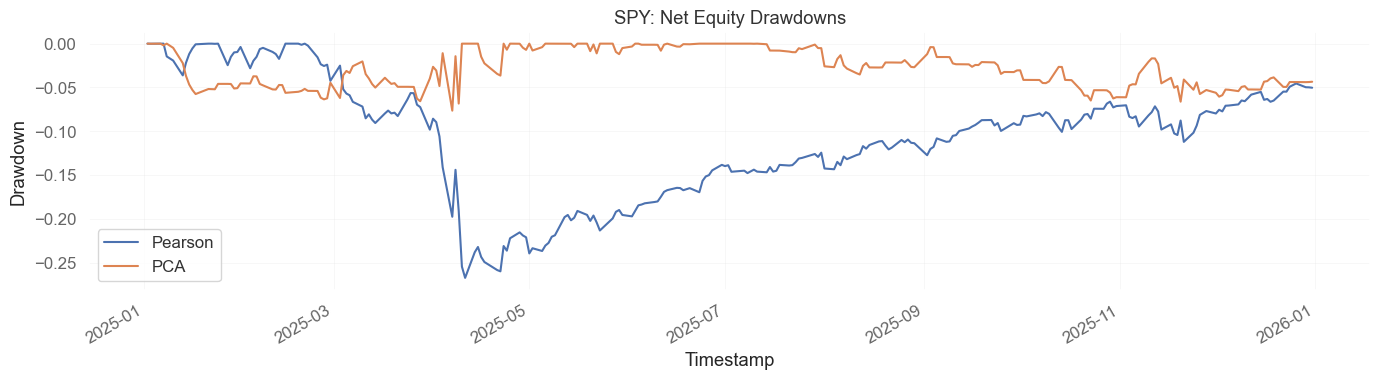

In [9]:
drawdowns = {}
for label, result in results.items():
    net_equity = result["stats"]["net_equity"]
    drawdowns[label] = net_equity / net_equity.cummax() - 1.0

drawdown_df = pd.DataFrame(drawdowns)

ax = drawdown_df.plot(figsize=(14, 4), title=f"{SYMBOL}: Net Equity Drawdowns")
ax.set_ylabel("Drawdown")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Signal and Exposure Comparison

Two methods can have similar returns for very different reasons. This section checks whether PCA changes the strategy's activity level or directional exposure.

,Pearson,PCA
count,250.0000,250.0000
mean,0.8280,0.0040
std,0.5583,0.8712
min,-1.0000,-1.0000
25%,1.0000,-1.0000
50%,1.0000,0.0000
75%,1.0000,1.0000
max,1.0000,1.0000


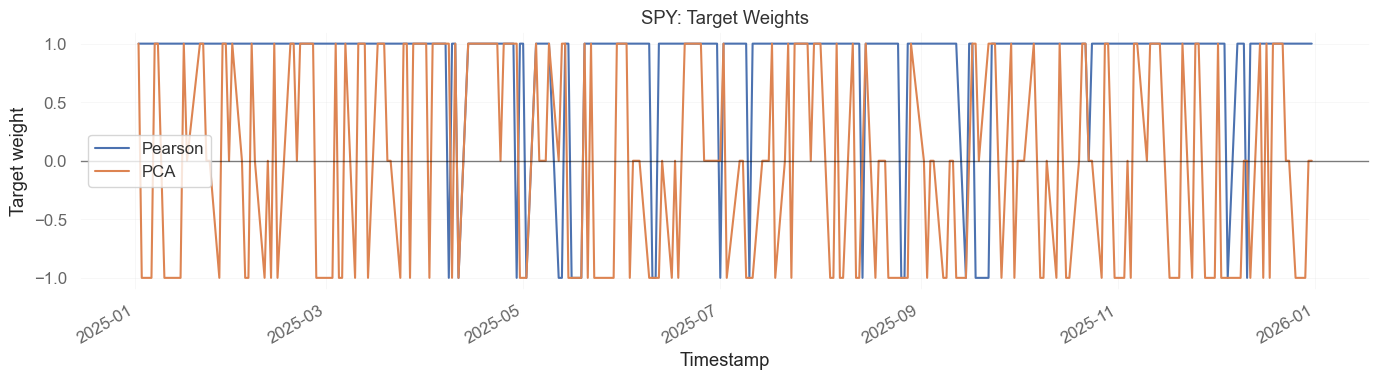

In [10]:
weight_df = pd.concat(
    {label: result["weights"][SYMBOL] for label, result in results.items()},
    axis=1,
)

display(weight_df.describe().round(4))

ax = weight_df.plot(figsize=(14, 4), title=f"{SYMBOL}: Target Weights")
ax.axhline(0, color="black", linewidth=1, alpha=0.5)
ax.set_ylabel("Target weight")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Pearson Diagnostics

The Pearson model keeps original columns. Its diagnostics therefore answer: *which raw indicators were selected most often?*

,prediction_date,feature,pearson_abs_corr,rank,selected
0,2025-01-02,ADOSC_3_10,0.046265,1,True
1,2025-01-02,PSARaf_0.02_0.2,0.045174,2,True
2,2025-01-02,CPR_WIDTH_PCT,0.043376,3,True
3,2025-01-02,RVGI_14_4,0.039717,4,True
4,2025-01-02,CPR_WIDTH,0.039574,5,True
5,2025-01-02,BBP_5_2.0,0.039366,6,True
6,2025-01-02,AR_26,0.038772,7,False
7,2025-01-02,CDL_3LINESTRIKE,0.038290,8,False
8,2025-01-02,RVGIh_14_4,0.037884,9,False
9,2025-01-02,EOM_14_100000000,0.037423,10,False


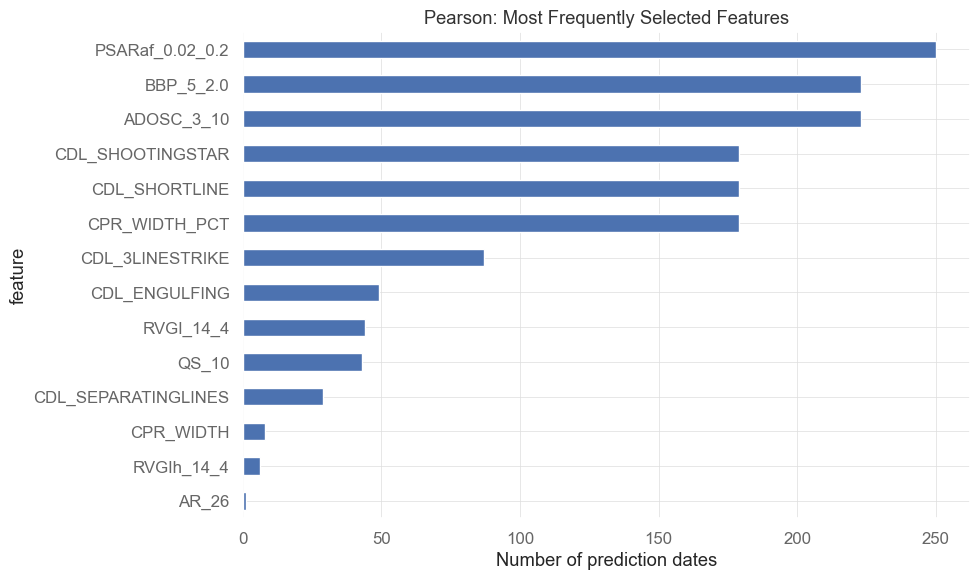

In [16]:
pearson_diag = pearson_result["strategy"].feature_selection_diagnostics_.copy()

display(pearson_diag.head(20))

pearson_selected = pearson_diag[pearson_diag["selected"]]
pearson_feature_counts = pearson_selected["feature"].value_counts().head(20).sort_values()

ax = pearson_feature_counts.plot(kind="barh", figsize=(10, 6), title="Pearson: Most Frequently Selected Features")
ax.set_xlabel("Number of prediction dates")
plt.tight_layout()
plt.show()

## 9. PCA Diagnostics

The PCA model does not select original columns directly. Its diagnostics answer two different questions:

1. How many principal components were retained through time?
2. Which original indicators most often had large loadings inside those components?

In [34]:
pca_diag = pca_result["strategy"].feature_selection_diagnostics_.copy()

display(pca_diag.head(22))

pca_component_summary = (
    pca_diag
    .groupby("prediction_date")
    .agg(
        n_components=("n_components", "max"),
        cumulative_explained_variance=("cumulative_explained_variance", "max"),
    )
)

display(pca_component_summary.describe().round(4))

,prediction_date,component,feature,loading,abs_loading,rank,explained_variance_ratio,cumulative_explained_variance,n_components,selected
0,2025-01-02,PC1,TEMA_10,0.080442,0.080442,1,0.361762,0.361762,86,True
1,2025-01-02,PC1,TSF_14,0.080435,0.080435,2,0.361762,0.361762,86,True
2,2025-01-02,PC1,LDECAY_5,0.080432,0.080432,3,0.361762,0.361762,86,True
3,2025-01-02,PC1,ZL_EMA_10,0.080432,0.080432,4,0.361762,0.361762,86,True
4,2025-01-02,PC1,High,0.080432,0.080432,5,0.361762,0.361762,86,True
5,2025-01-02,PC1,DEMA_10,0.080432,0.080432,6,0.361762,0.361762,86,True
6,2025-01-02,PC1,LR_14,0.080431,0.080431,7,0.361762,0.361762,86,True
7,2025-01-02,PC1,MIDPOINT_2,0.080430,0.080430,8,0.361762,0.361762,86,True
8,2025-01-02,PC1,RAINBOW_1,0.080430,0.080430,9,0.361762,0.361762,86,True
9,2025-01-02,PC1,VWAP_D,0.080429,0.080429,10,0.361762,0.361762,86,True


,n_components,cumulative_explained_variance
count,250.0,250.0000
mean,86.0,0.9507
std,0.0,0.0003
min,86.0,0.9502
25%,86.0,0.9505
50%,86.0,0.9506
75%,86.0,0.9511
max,86.0,0.9512


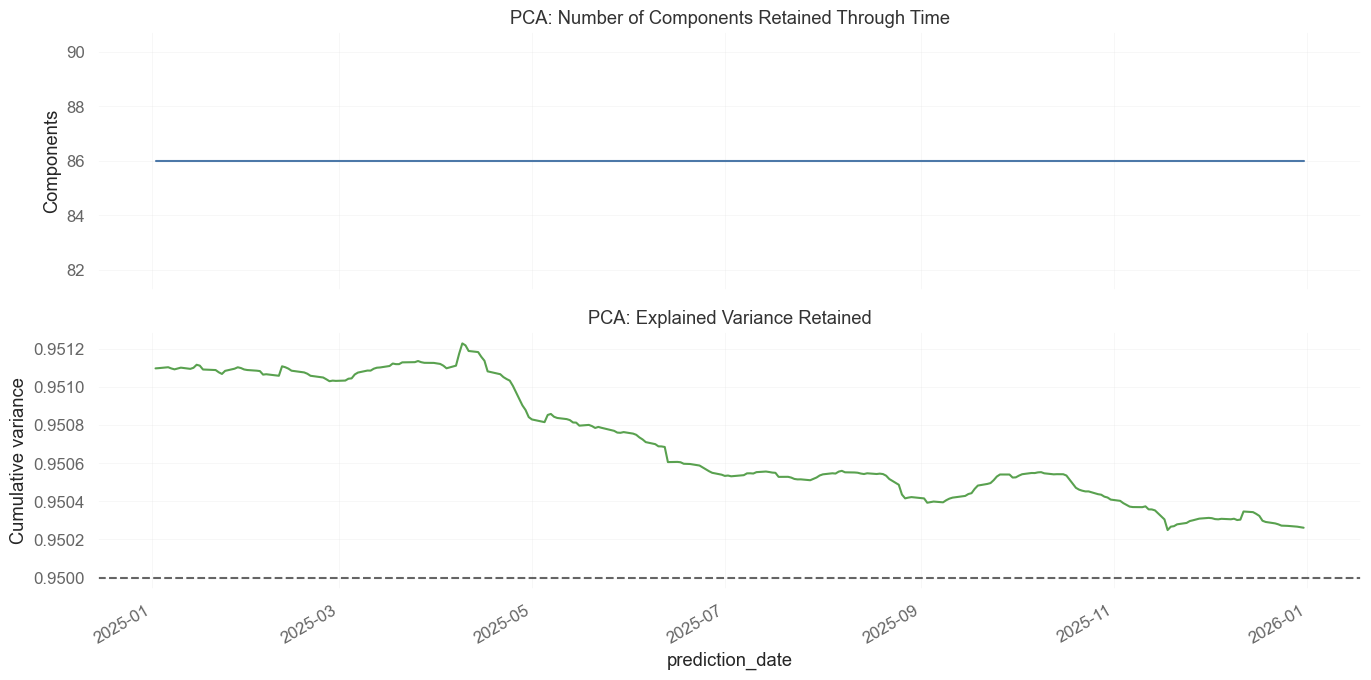

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

pca_component_summary["n_components"].plot(ax=axes[0], color="#4C78A8")
axes[0].set_title("PCA: Number of Components Retained Through Time")
axes[0].set_ylabel("Components")
axes[0].grid(True, alpha=0.3)

pca_component_summary["cumulative_explained_variance"].plot(ax=axes[1], color="#59A14F")
if isinstance(PCA_PARAMS["pca_n_components"], float):
    axes[1].axhline(PCA_PARAMS["pca_n_components"], color="black", linestyle="--", alpha=0.6)
axes[1].set_title("PCA: Explained Variance Retained")
axes[1].set_ylabel("Cumulative variance")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

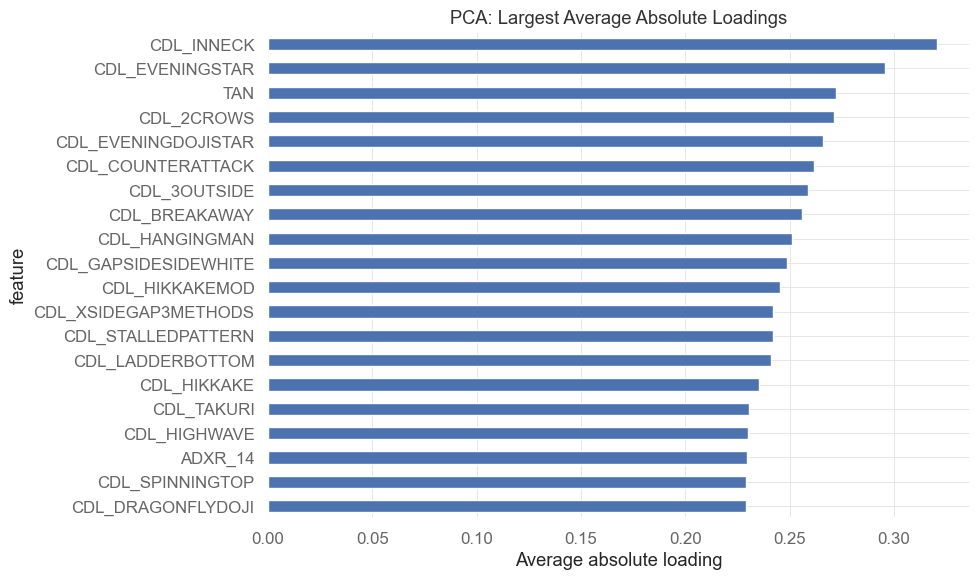

In [14]:
pca_top_loading_features = (
    pca_diag
    .groupby("feature")["abs_loading"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .sort_values()
)

ax = pca_top_loading_features.plot(kind="barh", figsize=(10, 6), title="PCA: Largest Average Absolute Loadings")
ax.set_xlabel("Average absolute loading")
plt.tight_layout()
plt.show()

## 10. Optional PCA Sensitivity Sweep

The main comparison uses `pca_n_components=0.95`. To learn whether PCA performance is sensitive to this choice, set `RUN_PCA_SWEEP = True` and run the cell below. Integer values test fixed component counts; float values test explained-variance thresholds.

In [35]:
RUN_PCA_SWEEP = True
PCA_SWEEP_VALUES = [3, 6, 10, 0.90, 0.95, 0.99]

if RUN_PCA_SWEEP:
    sweep_results = []
    for value in PCA_SWEEP_VALUES:
        params = {**COMMON_STRATEGY_PARAMS, "pca_n_components": value}
        result = run_backtest_case(
            label=f"PCA {value}",
            strategy_class=PCAStrategy,
            params=params,
            run_config=RUN_CONFIG,
            show_progress=SHOW_PROGRESS,
            show_tearsheet=False,
        )
        row = result["metrics"]
        row["pca_n_components"] = value
        sweep_results.append(row)

    pca_sweep = pd.DataFrame(sweep_results).set_index("pca_n_components")
    display(pca_sweep.round(4))
else:
    print("PCA sweep is disabled. Set RUN_PCA_SWEEP = True to run it.")

Running PCA 3...
🧠 Predicting 2025-12-31 |  250/250 |  last: 0.20s |  elapsed: 47.2s72/250 |  last: 0.20s |  elapsed: 13.3s 77/250 |  last: 0.20s |  elapsed: 14.2s 104/250 |  last: 0.20s |  elapsed: 19.1s
✅ Prediction complete. Took 47.3s

Running PCA 6...
🧠 Predicting 2025-12-31 |  250/250 |  last: 0.44s |  elapsed: 1m 28.1s
✅ Prediction complete. Took 1m 28.4s

Running PCA 10...
🧠 Predicting 2025-12-31 |  250/250 |  last: 0.61s |  elapsed: 2m 29.6s
✅ Prediction complete. Took 2m 30.3s

Running PCA 0.9...
🧠 Predicting 2025-12-31 |  250/250 |  last: 2.32s |  elapsed: 9m 10.3s
✅ Prediction complete. Took 9m 12.6s

Running PCA 0.95...
🧠 Predicting 2025-12-31 |  250/250 |  last: 1.54s |  elapsed: 6m 35.2s
✅ Prediction complete. Took 6m 36.8s

Running PCA 0.99...
🧠 Predicting 2025-12-31 |  250/250 |  last: 1.41s |  elapsed: 5m 11.7s
✅ Prediction complete. Took 5m 13.1s



,method,gross_return_pct,net_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,net_sharpe,net_sortino,win_rate_pct,loss_rate_pct,zero_rate_pct,active_days_pct,average_abs_exposure,average_daily_turnover,total_fees_paid
pca_n_components,,,,,,,,,,,,,,,
3.00,PCA 3,-8.4598,-9.3002,17.954,-27.2542,-25.2312,-0.3876,-0.4626,42.9719,40.9639,16.0643,84.8,0.848,0.312,8403.5566
6.00,PCA 6,10.1233,8.5375,17.954,-9.4166,-11.8644,0.5555,0.6966,47.7912,36.1446,16.0643,84.8,0.848,0.528,15858.1205
10.00,PCA 10,-10.9763,-12.8124,17.954,-30.7664,-25.6988,-0.5925,-0.7813,45.3815,41.7671,12.8514,88.0,0.880,0.616,18360.2644
0.90,PCA 0.9,-18.1255,-20.2387,17.954,-38.1927,-23.3456,-1.0602,-1.1812,37.3494,37.3494,25.3012,74.8,0.748,0.792,21131.8403
0.95,PCA 0.95,21.8225,19.0013,17.954,1.0472,-7.6500,0.9964,1.4050,38.9558,36.5462,24.4980,75.6,0.756,0.820,28212.1165
0.99,PCA 0.99,32.5305,29.6019,17.954,11.6479,-7.1347,1.5995,2.7167,40.5622,34.1365,25.3012,74.4,0.744,0.836,29286.5287


## 11. Interpretation Checklist

Use this checklist after the runs complete:

- Did PCA improve net return, or only gross return before costs?
- Did PCA reduce drawdown, or merely change the timing of losses?
- Did PCA increase turnover and fees?
- Did PCA produce more active days or more zero-weight days?
- If `pca_n_components` is a variance threshold, how stable was the number of retained components?
- Do the PCA loading diagnostics concentrate around a small set of indicators, or are the components broad mixtures?

A better PCA result is most convincing when it improves net return or risk-adjusted return without simply buying that improvement through materially higher turnover or hidden fragility in the retained-component count.